# Thalassemia Patient Analysis Pipeline
**Dataset:** 1073 real HPLC patient records — Ibn Al-Baladi Hospital, Baghdad (2022)  
**Tools:** Python, pandas, DuckDB (SQL), Matplotlib  
**Goal:** Identify anemia prevalence, HBA2 elevation patterns, and clinical KPIs 
across age groups and gender using an end-to-end data pipeline.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("thalassimia.xlsx")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1073, 18)

Columns: ['ID', 'Gender', 'Age', 'MCV', 'HBG', 'MCH', 'RBC', 'S', 'HBA2', 'HBA', 'HBF', 'Iron', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17']

First 5 rows:


,ID,Gender,Age,MCV,HBG,MCH,RBC,S,HBA2,HBA,HBF,Iron,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,1,1,30.0,63.9,11.5,20.4,NaN,NaN,5.8,92.1,1.7,9.6,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0,14.0,62.0,7.0,17.8,NaN,NaN,2.2,97.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,29.0,72.0,16.8,24.1,NaN,NaN,3.5,96.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0,27.0,61.0,8.5,24.6,NaN,NaN,2.3,97.6,NaN,0.1,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,2.0,53.6,8.9,17.0,NaN,NaN,2.5,97.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Drop unnamed junk columns
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

# Rename HBG to HGB (typo in dataset)
df.rename(columns={'HBG': 'HGB'}, inplace=True)

# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nShape after cleaning:", df.shape)
print("\nData types:")
print(df.dtypes)

Missing values per column:
ID           0
Gender       0
Age          0
MCV         19
HGB         19
MCH         41
RBC        926
S         1054
HBA2         5
HBA          4
HBF        585
Iron       827
dtype: int64

Shape after cleaning: (1073, 12)

Data types:
ID          int64
Gender      int64
Age       float64
MCV       float64
HGB       float64
MCH       float64
RBC       float64
S         float64
HBA2       object
HBA       float64
HBF       float64
Iron      float64
dtype: object


In [11]:
# Find and fix dirty string values
for col in ['MCV', 'HGB', 'MCH', 'HBA2', 'HBA']:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # converts bad values to NaN

# Now fill missing values with median
for col in ['MCV', 'HGB', 'MCH', 'HBA2', 'HBA']:
    df[col].fillna(df[col].median(), inplace=True)

# Feature Engineering
df['HBA2_elevated'] = df['HBA2'].apply(lambda x: 1 if x > 3.5 else 0)
df['anemia_flag'] = df['HGB'].apply(lambda x: 1 if x < 11 else 0)
df['age_group'] = pd.cut(df['Age'], bins=[0,12,18,40,100],
                         labels=['Child','Teen','Adult','Senior'])

print("Final shape:", df.shape)
print("\nCleaning done. Sample:")
df.head()

Final shape: (1073, 15)

Cleaning done. Sample:


/var/folders/5_/znb1_xf91q14xnvgxtkj43zc0000gn/T/ipykernel_54802/3642849835.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
/var/folders/5_/znb1_xf91q14xnvgxtkj43zc0000gn/T/ipykernel_54802/3642849835.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Serie

,ID,Gender,Age,MCV,HGB,MCH,RBC,S,HBA2,HBA,HBF,Iron,HBA2_elevated,anemia_flag,age_group
0,1,1,30.0,63.9,11.5,20.4,NaN,NaN,5.8,92.1,1.7,9.6,1,0,Adult
1,2,0,14.0,62.0,7.0,17.8,NaN,NaN,2.2,97.8,NaN,NaN,0,1,Teen
2,3,1,29.0,72.0,16.8,24.1,NaN,NaN,3.5,96.3,NaN,NaN,0,0,Adult
3,4,0,27.0,61.0,8.5,24.6,NaN,NaN,2.3,97.6,NaN,0.1,0,1,Adult
4,5,1,2.0,53.6,8.9,17.0,NaN,NaN,2.5,97.5,NaN,NaN,0,1,Child


In [12]:
# Install duckdb if not already
import subprocess
subprocess.run(['pip', 'install', 'duckdb'], capture_output=True)

import duckdb

# Run SQL queries directly on the dataframe
con = duckdb.connect()

# Query 1: Average HGB and MCV by gender
print("=== Average HGB & MCV by Gender ===")
print(con.execute("""
    SELECT 
        CASE WHEN Gender = 1 THEN 'Male' ELSE 'Female' END as Gender,
        ROUND(AVG(HGB), 2) as Avg_Hemoglobin,
        ROUND(AVG(MCV), 2) as Avg_MCV,
        COUNT(*) as Total_Patients
    FROM df
    GROUP BY Gender
""").df())

# Query 2: HBA2 elevation rate by age group
print("\n=== HBA2 Elevation Rate by Age Group ===")
print(con.execute("""
    SELECT 
        age_group,
        COUNT(*) as Total,
        SUM(HBA2_elevated) as Elevated_Count,
        ROUND(SUM(HBA2_elevated) * 100.0 / COUNT(*), 1) as Elevation_Pct
    FROM df
    GROUP BY age_group
    ORDER BY age_group
""").df())

# Query 3: Anemia flag summary
print("\n=== Anemia Prevalence ===")
print(con.execute("""
    SELECT 
        CASE WHEN anemia_flag = 1 THEN 'Anemic' ELSE 'Normal' END as Status,
        COUNT(*) as Count,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM df), 1) as Percentage
    FROM df
    GROUP BY anemia_flag
""").df())

=== Average HGB & MCV by Gender ===
   Gender  Avg_Hemoglobin  Avg_MCV  Total_Patients
0    Male           12.91    69.50             416
1  Female           10.84    68.29             657

=== HBA2 Elevation Rate by Age Group ===
  age_group  Total  Elevated_Count  Elevation_Pct
0     Child    349           121.0           34.7
1      Teen    154            49.0           31.8
2     Adult    485           148.0           30.5
3    Senior     84            34.0           40.5
4       NaN      1             1.0          100.0

=== Anemia Prevalence ===
   Status  Count  Percentage
0  Anemic    521        48.6
1  Normal    552        51.4


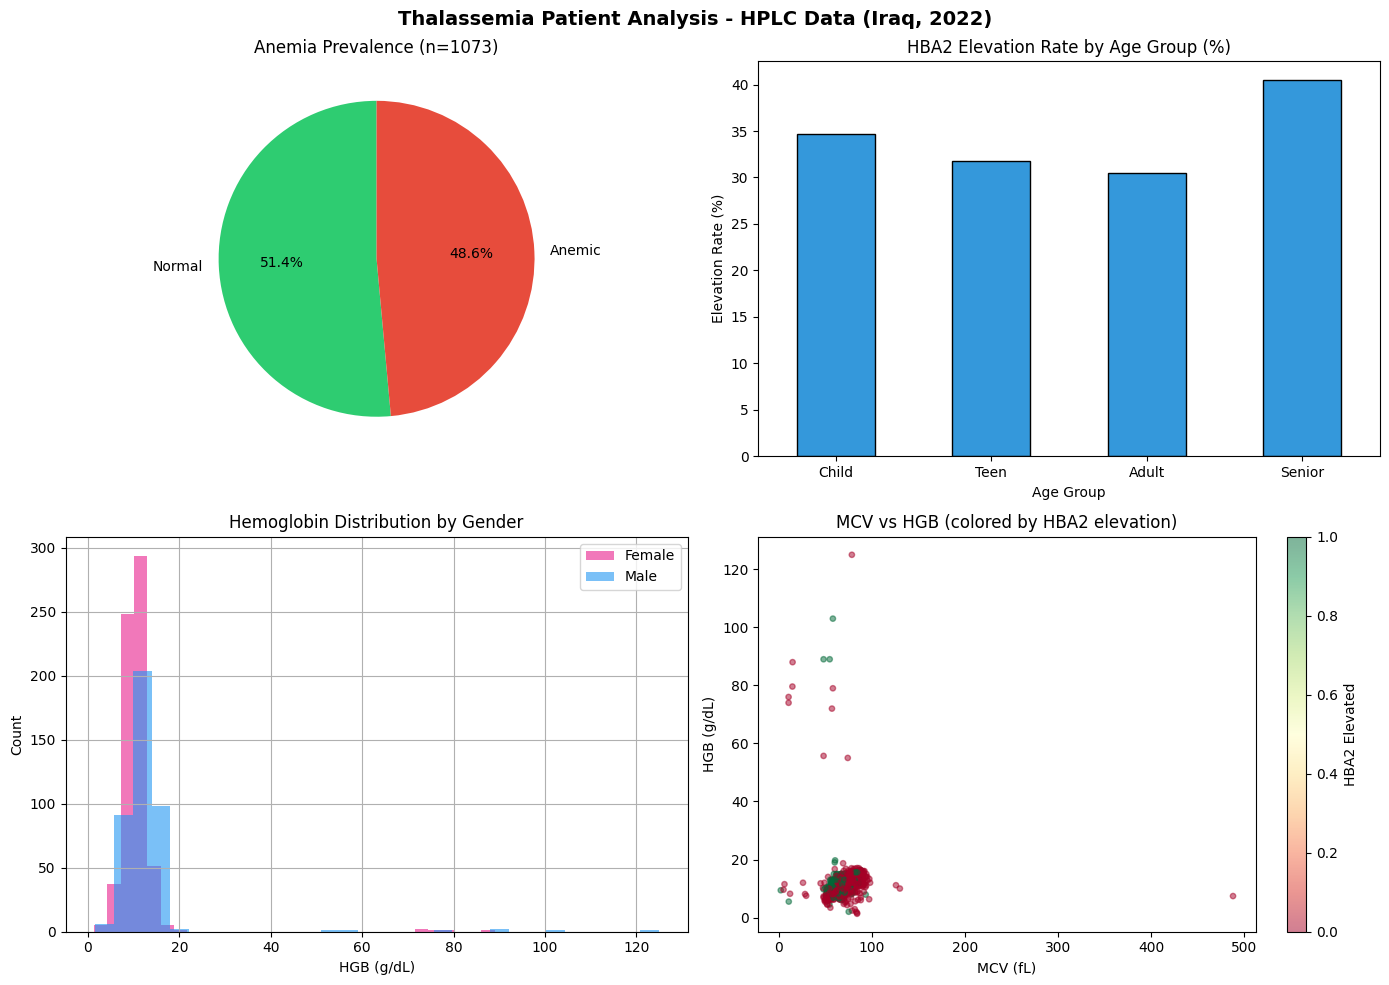

Chart saved!


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Thalassemia Patient Analysis - HPLC Data (Iraq, 2022)', 
             fontsize=14, fontweight='bold')

# Chart 1: Anemia Prevalence
axes[0,0].pie([552, 521], labels=['Normal', 'Anemic'], 
              autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
              startangle=90)
axes[0,0].set_title('Anemia Prevalence (n=1073)')

# Chart 2: HBA2 Elevation by Age Group
age_data = df.groupby('age_group', observed=True)['HBA2_elevated'].mean() * 100
age_data.plot(kind='bar', ax=axes[0,1], color='#3498db', edgecolor='black')
axes[0,1].set_title('HBA2 Elevation Rate by Age Group (%)')
axes[0,1].set_xlabel('Age Group')
axes[0,1].set_ylabel('Elevation Rate (%)')
axes[0,1].tick_params(axis='x', rotation=0)

# Chart 3: HGB distribution by Gender
df[df['Gender']==0]['HGB'].hist(ax=axes[1,0], alpha=0.6, 
                                 color='#e91e8c', label='Female', bins=30)
df[df['Gender']==1]['HGB'].hist(ax=axes[1,0], alpha=0.6, 
                                 color='#2196f3', label='Male', bins=30)
axes[1,0].set_title('Hemoglobin Distribution by Gender')
axes[1,0].set_xlabel('HGB (g/dL)')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Chart 4: MCV vs HGB scatter
scatter = axes[1,1].scatter(df['MCV'], df['HGB'], 
                             c=df['HBA2_elevated'], 
                             cmap='RdYlGn', alpha=0.5, s=15)
axes[1,1].set_title('MCV vs HGB (colored by HBA2 elevation)')
axes[1,1].set_xlabel('MCV (fL)')
axes[1,1].set_ylabel('HGB (g/dL)')
plt.colorbar(scatter, ax=axes[1,1], label='HBA2 Elevated')

plt.tight_layout()
plt.savefig('thalassemia_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Key Findings
- **48.6%** of patients showed anemia (HGB < 11 g/dL)
- **Children** had the highest HBA2 elevation rate at **34.7%**
- **Seniors** showed highest elevation among adults at **40.5%**
- Female patients (657) significantly outnumbered male patients (416)
- Average hemoglobin was lower in females (10.84) vs males (12.91 g/dL)